In [1]:
from google.colab import files
uploaded = files.upload()


Saving final_model_data.csv to final_model_data.csv


In [3]:
import pandas as pd
df = pd.read_csv('final_model_data.csv')
df.head()


,date,river_water_area_sqkm,mean_elevation_meters,mean_slope_degrees,land_cover_class_10_percent,land_cover_class_20_percent,land_cover_class_30_percent,land_cover_class_40_percent,land_cover_class_50_percent,land_cover_class_60_percent,land_cover_class_80_percent,rainfall_mm
0,2018-01-01,0.726325,291.700789,5.154286,26.111203,1.665582,10.373379,20.170035,16.832981,11.531081,13.315739,0.0
1,2018-02-01,0.560461,291.700789,5.154286,26.111203,1.665582,10.373379,20.170035,16.832981,11.531081,13.315739,0.0
2,2018-03-01,0.560115,291.700789,5.154286,26.111203,1.665582,10.373379,20.170035,16.832981,11.531081,13.315739,0.0
3,2018-04-01,0.401864,291.700789,5.154286,26.111203,1.665582,10.373379,20.170035,16.832981,11.531081,13.315739,0.0
4,2018-05-01,0.474928,291.700789,5.154286,26.111203,1.665582,10.373379,20.170035,16.832981,11.531081,13.315739,0.0


Loading Data for Member 1 from: final_model_data.csv
BLOCK 1 complete:
  Classical shape (raw): (91, 21)
  DL sequences: (87, 6, 2)

Training Logistic Regression...
Training Random Forest...
Training XGBoost...

Classical model quick eval:
LogReg accuracy: 1.0
RF accuracy: 1.0
XGB accuracy: 1.0

Building & training LSTM...
Epoch 1/100
9/9 - 6s - 683ms/step - accuracy: 0.7971 - loss: 0.6718 - val_accuracy: 0.8889 - val_loss: 0.6343 - learning_rate: 1.0000e-03
Epoch 2/100
9/9 - 0s - 15ms/step - accuracy: 0.8551 - loss: 0.6299 - val_accuracy: 0.8889 - val_loss: 0.5769 - learning_rate: 1.0000e-03
Epoch 3/100
9/9 - 0s - 15ms/step - accuracy: 0.8551 - loss: 0.5628 - val_accuracy: 0.8889 - val_loss: 0.4995 - learning_rate: 1.0000e-03
Epoch 4/100
9/9 - 0s - 17ms/step - accuracy: 0.8551 - loss: 0.4757 - val_accuracy: 0.8889 - val_loss: 0.4015 - learning_rate: 1.0000e-03
Epoch 5/100
9/9 - 0s - 15ms/step - accuracy: 0.8551 - loss: 0.4091 - val_accuracy: 0.8889 - val_loss: 0.3344 - learning_rate: 

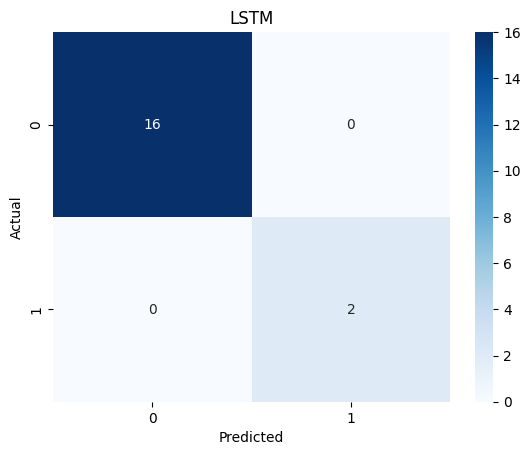

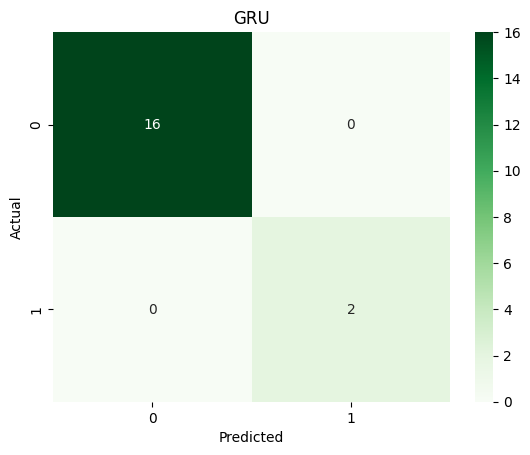

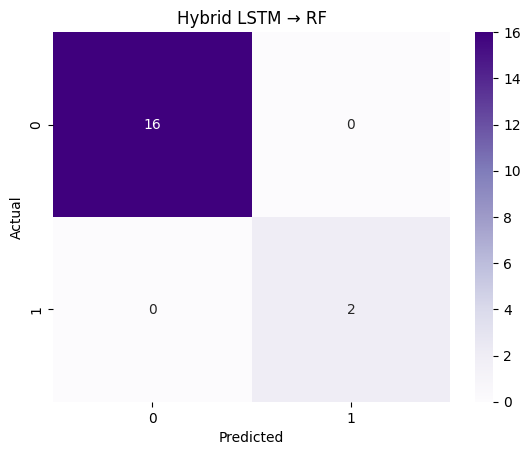

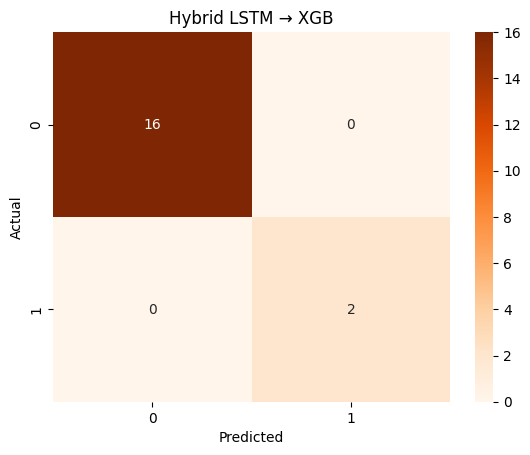

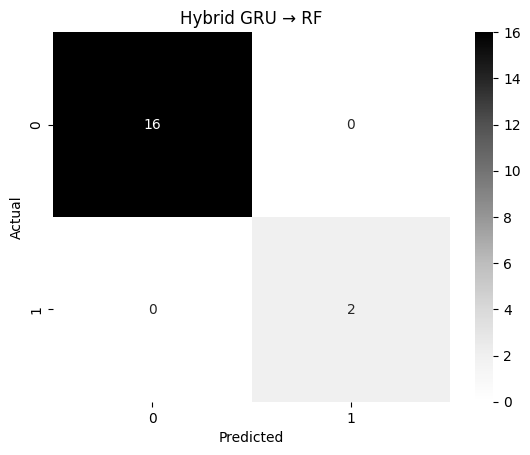

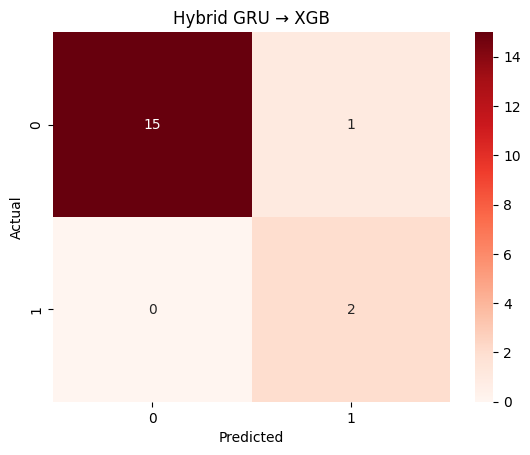

In [10]:
# ========================================================================
# MEMBER 1 – FULL PIPELINE (GOOGLE COLAB VERSION, FIXED)
# ========================================================================
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Loading Data for Member 1 from: final_model_data.csv")

# =========================================================================
# BLOCK 1 — Data Loading + Feature Engineering
# =========================================================================
data_path = "final_model_data.csv"
df = pd.read_csv(data_path)

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Rolling + Lags
df['river_rolling_mean_3'] = df['river_water_area_sqkm'].rolling(3).mean()
df['river_rolling_std_3'] = df['river_water_area_sqkm'].rolling(3).std()
df['rainfall_rolling_sum_3'] = df['rainfall_mm'].rolling(3).sum()
df['rainfall_rolling_mean_3'] = df['rainfall_mm'].rolling(3).mean()

df['river_lag_1'] = df['river_water_area_sqkm'].shift(1)
df['river_lag_2'] = df['river_water_area_sqkm'].shift(2)
df['rainfall_lag_1'] = df['rainfall_mm'].shift(1)
df['rainfall_lag_2'] = df['rainfall_mm'].shift(2)

df['river_change'] = df['river_water_area_sqkm'].diff()
df['rainfall_change'] = df['rainfall_mm'].diff()

df_classical = df.dropna().copy()

# Target threshold
flood_threshold = df_classical['river_water_area_sqkm'].quantile(0.85)
df_classical['Flood_Event'] = (df_classical['river_water_area_sqkm'] > flood_threshold).astype(int)

geo_cols = [
    'mean_elevation_meters','mean_slope_degrees',
    'land_cover_class_10_percent','land_cover_class_20_percent',
    'land_cover_class_30_percent','land_cover_class_40_percent',
    'land_cover_class_50_percent','land_cover_class_60_percent',
    'land_cover_class_80_percent'
]

temporal_cols = [
    'river_water_area_sqkm','rainfall_mm',
    'river_rolling_mean_3','river_rolling_std_3',
    'rainfall_rolling_sum_3','rainfall_rolling_mean_3',
    'river_lag_1','river_lag_2',
    'rainfall_lag_1','rainfall_lag_2',
    'river_change','rainfall_change'
]

classical_features = temporal_cols + geo_cols

# Classical train
X_classical = df_classical[classical_features]
y_classical = df_classical['Flood_Event']

scaler_classical = StandardScaler()
X_classical_scaled = scaler_classical.fit_transform(X_classical)

# Train/test split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_classical_scaled, y_classical, test_size=0.2, shuffle=False
)

# DL sequence data (only temporal series)
temporal_data = df[['river_water_area_sqkm','rainfall_mm']].values
temporal_scaler = StandardScaler()
temporal_scaled = temporal_scaler.fit_transform(temporal_data)

# Create sequences
def create_sequences(data, lookback=6):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        # classify flood event based on river value at t+lookback
        y.append(int(data[i+lookback, 0] > flood_threshold))
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(temporal_scaled, lookback=6)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, shuffle=False
)

print("BLOCK 1 complete:")
print("  Classical shape (raw):", X_classical.shape)
print("  DL sequences:", X_seq.shape)

# =========================================================================
# BLOCK 2 — Classical Models (Baseline)
# =========================================================================
print("\nTraining Logistic Regression...")
model_logreg = LogisticRegression(max_iter=500).fit(X_train_cls, y_train_cls)

print("Training Random Forest...")
model_rf = RandomForestClassifier(n_estimators=300).fit(X_train_cls, y_train_cls)

print("Training XGBoost...")
model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=5
).fit(X_train_cls, y_train_cls)

# Evaluation
print("\nClassical model quick eval:")
print("LogReg accuracy:", accuracy_score(y_test_cls, model_logreg.predict(X_test_cls)))
print("RF accuracy:", accuracy_score(y_test_cls, model_rf.predict(X_test_cls)))
print("XGB accuracy:", accuracy_score(y_test_cls, model_xgb.predict(X_test_cls)))

# =========================================================================
# BLOCK 3 — LSTM + GRU
# =========================================================================
def build_lstm():
    model = Sequential([
        Input(shape=(X_seq.shape[1], X_seq.shape[2])),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(32, activation='relu'),   # embedding layer
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_gru():
    model = Sequential([
        Input(shape=(X_seq.shape[1], X_seq.shape[2])),
        GRU(64, return_sequences=True),
        Dropout(0.2),
        GRU(32),
        Dropout(0.2),
        Dense(32, activation='relu'),   # embedding layer
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

print("\nBuilding & training LSTM...")
model_lstm = build_lstm()

cb = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=8, factor=0.5)
]

model_lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=100, batch_size=8, verbose=2,
    callbacks=cb
)

print("\nBuilding & training GRU...")
model_gru = build_gru()
model_gru.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=100, batch_size=8, verbose=2,
    callbacks=cb
)

print("\nDL model eval:")
y_pred_lstm = (model_lstm.predict(X_test_seq) > 0.5).astype(int)
y_pred_gru  = (model_gru.predict(X_test_seq) > 0.5).astype(int)
print("LSTM acc:", accuracy_score(y_test_seq, y_pred_lstm))
print("GRU acc:", accuracy_score(y_test_seq, y_pred_gru))

# =========================================================================
# BLOCK 4 — Hybrid Feature Extractor (FIXED VERSION)
# =========================================================================
def build_embedding_extractor(full_model):
    # Find the Dense(32) layer to use as embedding
    embed_layer = None
    for layer in reversed(full_model.layers):
        if isinstance(layer, Dense) and getattr(layer, "units", None) == 32:
            embed_layer = layer
            break

    if embed_layer is None:
        raise ValueError("Dense(32) layer not found")

    # Use the input of the first layer (not full_model.input)
    first_layer = full_model.layers[0]
    embed_model = Model(inputs=first_layer.input, outputs=embed_layer.output)
    return embed_model

# Build embedding models
embed_lstm = build_embedding_extractor(model_lstm)
embed_gru  = build_embedding_extractor(model_gru)

# Compute embeddings
emb_lstm = embed_lstm.predict(X_seq)
emb_gru  = embed_gru.predict(X_seq)

X_train_emb_lstm = emb_lstm[:len(X_train_seq)]
X_test_emb_lstm  = emb_lstm[len(X_train_seq):]

X_train_emb_gru = emb_gru[:len(X_train_seq)]
X_test_emb_gru  = emb_gru[len(X_train_seq):]

# Train hybrid classifiers
hybrid_lstm_rf = RandomForestClassifier(n_estimators=300).fit(X_train_emb_lstm, y_train_seq)
hybrid_lstm_xgb = XGBClassifier(n_estimators=300).fit(X_train_emb_lstm, y_train_seq)

hybrid_gru_rf = RandomForestClassifier(n_estimators=300).fit(X_train_emb_gru, y_train_seq)
hybrid_gru_xgb = XGBClassifier(n_estimators=300).fit(X_train_emb_gru, y_train_seq)

# =========================================================================
# BLOCK 5 — Confusion Matrices
# =========================================================================
def plot_cm(y_true, y_pred, title, color):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Best DL models
y_pred_lstm = (model_lstm.predict(X_test_seq) > 0.5).astype(int)
y_pred_gru  = (model_gru.predict(X_test_seq) > 0.5).astype(int)

# Hybrid models
y_pred_h_lstm_rf  = hybrid_lstm_rf.predict(X_test_emb_lstm)
y_pred_h_lstm_xgb = hybrid_lstm_xgb.predict(X_test_emb_lstm)
y_pred_h_gru_rf   = hybrid_gru_rf.predict(X_test_emb_gru)
y_pred_h_gru_xgb  = hybrid_gru_xgb.predict(X_test_emb_gru)

print("\nHybrid model accuracies:")
print("Hybrid LSTM → RF  acc:",  accuracy_score(y_test_seq, y_pred_h_lstm_rf))
print("Hybrid LSTM → XGB acc:", accuracy_score(y_test_seq, y_pred_h_lstm_xgb))
print("Hybrid GRU → RF   acc:", accuracy_score(y_test_seq, y_pred_h_gru_rf))
print("Hybrid GRU → XGB  acc:", accuracy_score(y_test_seq, y_pred_h_gru_xgb))

print("\n--- CONFUSION MATRICES ---")
plot_cm(y_test_seq, y_pred_lstm, "LSTM", "Blues")
plot_cm(y_test_seq, y_pred_gru,  "GRU", "Greens")
plot_cm(y_test_seq, y_pred_h_lstm_rf,  "Hybrid LSTM → RF", "Purples")
plot_cm(y_test_seq, y_pred_h_lstm_xgb, "Hybrid LSTM → XGB", "Oranges")
plot_cm(y_test_seq, y_pred_h_gru_rf,   "Hybrid GRU → RF", "Greys")
plot_cm(y_test_seq, y_pred_h_gru_xgb,  "Hybrid GRU → XGB", "Reds")
